<img src="https://www.unir.net/wp-content/uploads/2019/11/Unir_2021_logo.svg" width="240" height="240" align="right"/>

<center><h1>Técnicas de Inteligencia Artificial</header1></center>
<left><h1>Actividad 2. Trabajando con redes neuronales y Deep Learning</header1></left>

Presentado por: Fernando Espina Saavedra  <br>
Fecha: 18/05/2022

# Importación de librerias necesarias

In [1]:
#Para esta actividad se importarán las siguientes librerías:

# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesado y modelo alternativo (no basado en redes neuronales)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Red neuronal con Keras sobre TensorFlow 2.0
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Para que los resultados sean reproducibles 
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Ajustes viasuales para gráficas
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('TensorFlow:', tf.__version__)
print('Pandas:', pd.__version__)



TensorFlow: 2.21.0
Pandas: 2.3.3


# Parte I. Regresión

## Cargar el Dataset

Tal y como se pide en el enunciado del proyecto, ingererimos el dataset de forma automática, paro ello, hemos creado un repositorio público en GitHub. Además, este cuenta con al menos 1000 instancias y una variable/atributo de la salida, que depende de, al menos, 6 variables/atributos de entrada. 

In [2]:
# Código para cargar el Dataset

url = 'https://raw.githubusercontent.com/fernandoespinasv/regreclas-tecnicasIA-UNIR/35bcc775af0a3d0e45ac0217a93b505c008c43dd/spotify_songs.csv'

df = pd.read_csv(url)
print(f'Dataset cargado correctamente: {df.shape[0]} filas, {df.shape[1]} columnas.')
df.head()


Dataset cargado correctamente: 32833 filas, 23 columnas.


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


## Descripción de la fuente del Dataset

El dataset propuesto ha sido extraído de la plataforma online de **Kaggle** (https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs) y los datos de este fueron recogidos a través del paquete `spotifyr` que consume la API oficial de Spotify Web. Destacar también que esta fuente está bajo licencia CC0 y que es libremente reutilizable.

Contiene un total de **32.833 instancias** (canciones) con 23 atributos cada una, incluyendo metadatos del tema (nombre, artista, álbum), información de la playlist y, principalmente, **características de audio** (bailabilidad, energía, valencia, tempo, etc.).

## Explique el problema a resolver

Nuestro problema a resolver, es un problema de aprendizaje supervisado de **regresión**: nuestra variable objetivo será `track_popularity`, que toma valores en un rango continuo (de 0 a 100) e indica la popularidad de la canción en Spotify; mientras que nuestras variables de entrada serán las distintas características de audio:

| Variable | Descripción | Rango |
|---|---|---|
| `danceability` | Cómo de bailable es la canción | 0 – 1 |
| `energy` | Intensidad y actividad percibida | 0 – 1 |
| `key` | Tonalidad (escala) | 0 – 11 |
| `loudness` | Volumen medio en dB | aprox. –60 – 0 |
| `mode` | Modo (mayor=1 / menor=0) | 0 ó 1 |
| `speechiness` | Presencia de voz hablada | 0 – 1 |
| `acousticness` | Probabilidad de que sea acústica | 0 – 1 |
| `instrumentalness` | Probabilidad de ser instrumental | 0 – 1 |
| `liveness` | Detección de público en directo | 0 – 1 |
| `valence` | Positividad transmitida | 0 – 1 |
| `tempo` | Beats por minuto | aprox. 50 – 200 |
| `duration_ms` | Duración en milisegundos | — |

También valoraremos incluir la variable `playlist_genre` (variable categórica con 6 valores: pop, rap, rock, latin, r&b, edm), ya que el género es algo que por regla general suele influir bastante en la popularidad.

Destacar que un modelo de este tipo podría servir a discográficas o productores para estimar el potencial de nuevas canciones, además de por ejemplo a los DJs.

**Lo que queremos comprobar** es si realmente las características de audio se valen por sí solas y son capaces para explicar una parte razonable de la popularidad. Posteriormente, en el EDA, veremos que las correlaciones lineales con la popularidad son bastante bajas, por lo que una regresión lineal no daría mucho juego aquí. Es por ello que elegimos como modelo alternativo un Random Forest Regressor, que sabe capturar relaciones no lineales, quedando así la comparación con la red neuronal más justa.

## Caracterización del Dataset

Realizamos una descripción de los datos con:

>- Número de instancias en total.
>- Número de atributos de entrada, su significado y tipo.
>- Estadísticas de la variable objetivo.
>- Estadísticas de los atributos en relación con la variable objetivo.


In [3]:
# Vistazo general del dataset

print('Instancias y atributos:', df.shape)
print('\nTipos de datos:')
df.info()

Instancias y atributos: (32833, 23)

Tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key     

Vemos que hay **32.833 instancias** y **23 columnas**, una mezcla de `object` (textos/categóricas) y numéricas (`int64`/`float64`). Aunque tenemos 23 columnas, muchas de ellas son identificadores o metadatos (`track_id`, `track_name`, `track_artist`, etc.) que no son útiles para nuestro objetivo (los eliminaremos más adelante).

In [4]:
# Análisis descriptivo de las variables que usaremos para modelar

num_cols = ['track_popularity', 'danceability', 'energy', 'key', 'loudness', 'mode',
            'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence',
            'tempo', 'duration_ms']
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
track_popularity,32833.0,42.477081,24.984074,0.000000,24.0000,45.000000,62.00000,100.000
danceability,32833.0,0.654850,0.145085,0.000000,0.5630,0.672000,0.76100,0.983
energy,32833.0,0.698619,0.180910,0.000175,0.5810,0.721000,0.84000,1.000
key,32833.0,5.374471,3.611657,0.000000,2.0000,6.000000,9.00000,11.000
loudness,32833.0,-6.719499,2.988436,-46.448000,-8.1710,-6.166000,-4.64500,1.275
mode,32833.0,0.565711,0.495671,0.000000,0.0000,1.000000,1.00000,1.000
speechiness,32833.0,0.107068,0.101314,0.000000,0.0410,0.062500,0.13200,0.918
acousticness,32833.0,0.175334,0.219633,0.000000,0.0151,0.080400,0.25500,0.994
instrumentalness,32833.0,0.084747,0.224230,0.000000,0.0000,0.000016,0.00483,0.994
liveness,32833.0,0.190176,0.154317,0.000000,0.0927,0.127000,0.24800,0.996


Aquí, podemos observar cómo `track_popularity` tiene media en torno a 42-43 con bastante dispersión, que `instrumentalness` está muy sesgada hacia 0 (la mayoría de canciones tienen voz), así como que `loudness` y `tempo` tienen rangos muy distintos al resto de variables ([0,1]), por lo que **será obligatorio normalizar antes de entrenar la red**.

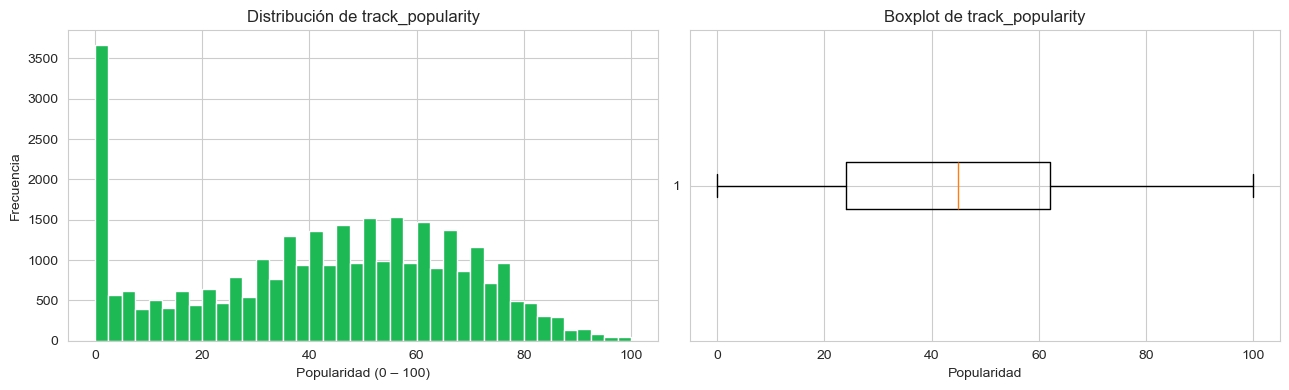

In [5]:
# Histograma de la popularidad

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['track_popularity'], bins=40, color='#1DB954', edgecolor='white')
axes[0].set_title('Distribución de track_popularity')
axes[0].set_xlabel('Popularidad (0 – 100)')
axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(df['track_popularity'], vert=False)
axes[1].set_title('Boxplot de track_popularity')
axes[1].set_xlabel('Popularidad')

plt.tight_layout()
plt.savefig('distribución_var_obj.png', dpi=150, bbox_inches='tight')
plt.show()

Observamos que obviamente, La popularidad NO se distribuye como una normal. Hay un pico claro en 0 y después, una distribución bastante amplia entre 30 y 70. Esto es interesante ya que el modelo va a tener que aprender a separar bien esas canciones "olvidadas" o impopulares. Antes de ver la correlación con nuestras variables de entradas, vamos a ver cómo se comporta nuestra variable objetivo con la variable categórica `playlist_genre` ya que como comentamos anteriormente, el género suele influir bastante en la popularidad.

C:\Users\Fernando\AppData\Local\Temp\ipykernel_16828\549946047.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='playlist_genre', y='track_popularity', ax=axes[1],


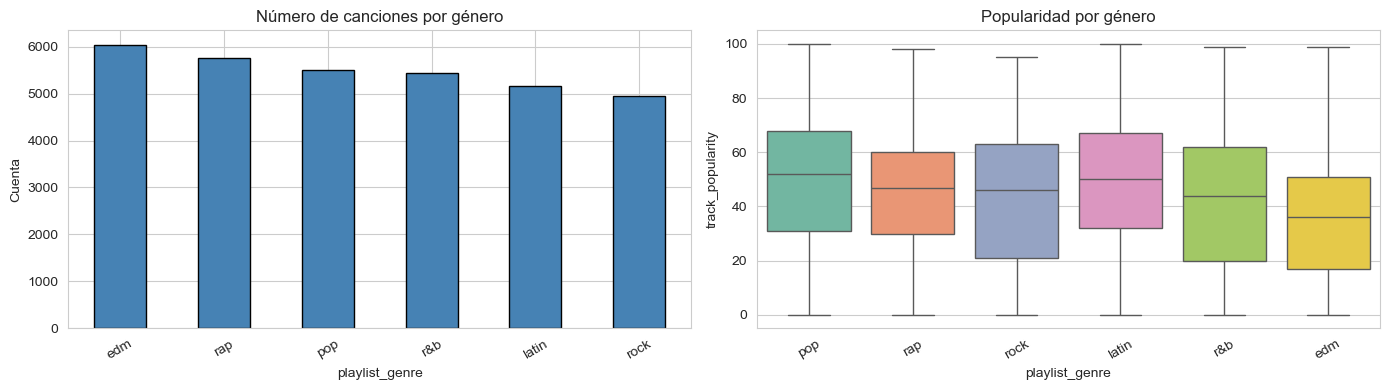

In [6]:
# Relación entre género y popularidad 

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['playlist_genre'].value_counts().plot(kind='bar', ax=axes[0],
                                          color='steelblue', edgecolor='black')
axes[0].set_title('Número de canciones por género')
axes[0].set_ylabel('Cuenta')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x='playlist_genre', y='track_popularity', ax=axes[1],
            palette='Set2')
axes[1].set_title('Popularidad por género')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('gen_vs_pop', dpi=150, bbox_inches='tight')
plt.show()

Aquí encontramos algo MUY interesante y es que aunque las clases están bastante equilibradas (en torno a 5.000–6.000 canciones por género); pop y latin lideran ligeramente. Esto justificaría incluir el género como feature predictiva.

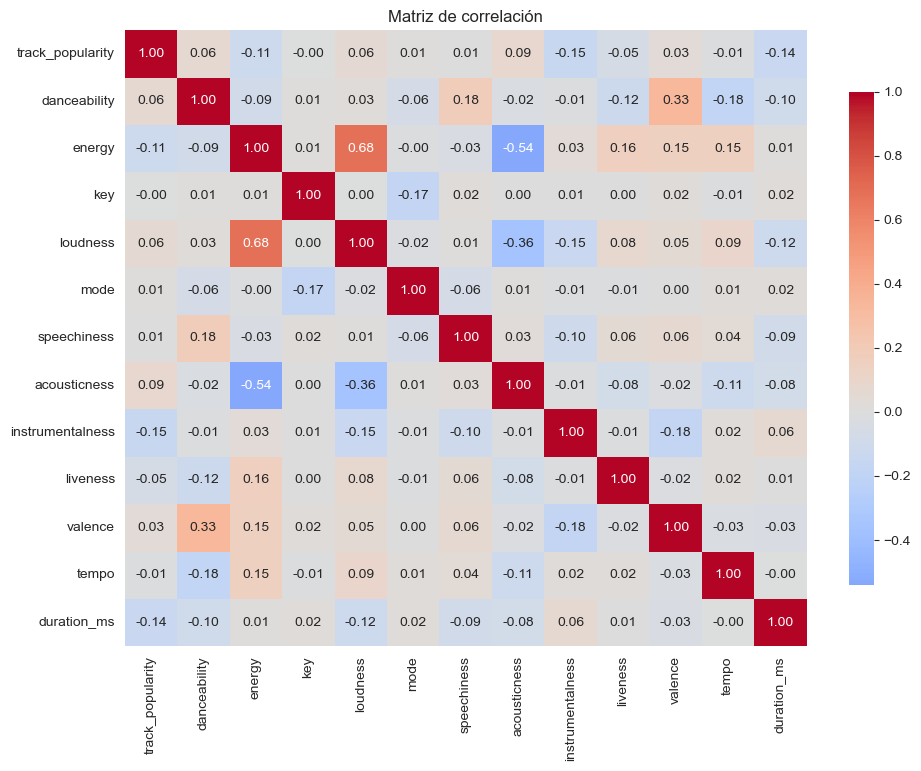

In [7]:
# Mapa de calor de correlaciones entre variables de entrada y variable objetivo

plt.figure(figsize=(11, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            cbar_kws={'shrink': .8})
plt.title('Matriz de correlación')
plt.savefig('mapa de calor', dpi=150, bbox_inches='tight')
plt.show()

Como esperaba, ninguna feature individual tiene una correlación lineal alta con `track_popularity` (está en valor absoluto en torno a 0.1–0.15). Esto confirma que el problema **no es lineal**: una regresión lineal va a tener un mal rendimiento y modelos como Random Forest o redes neuronales podrían ser de mayor utilidad. Algo que sí destaca es que correlación entre `loudness` y `energy` y entre `energy` y `acousticness`, pero eso es entre features, no afecta al target.

### Resumen de los principales hallazgos del EDA

1. **Tamaño:** 32.833 instancias y 23 atributos
2. **Variable objetivo:** distribución con moda en 0 y un cuerpo entre 30-70.
4. **Escalas muy distintas:** `tempo` (50-200) y `loudness` (negativo) frente al resto en [0,1]. Será necesario normalizar.
5. **Correlaciones lineales bajas con el target:** justifica usar modelos no-lineales.
6. **Géneros equilibrados** y con popularidad media distinta, por lo que conviene incluir `playlist_genre`.

## Preprocesamiento del dataset. Transformaciones previas necesarias para la modelación

Nuestro plan de preprocesado es:

1. Eliminar duplicados.
2. Descartar columnas de identificadores y metadatos que no aportan información a nuestro modelo.
3. Comprobar posibles valores nulos.
4. Usar One-hot encoding sobre `playlist_genre`.
5. Separar `X` (features) e `y` (target).
6. Escalar las features numéricas con `StandardScaler` (media 0, varianza 1). Esto es importante hacerlo **después** del split, así el escalador se ajusta solo con datos de entrenamiento y no hay filtración.

In [8]:
# Primero eliminamos los duplicados

df_clean = df.drop_duplicates(subset=['track_name', 'track_artist']).reset_index(drop=True)

# Ahora descartamos las columnas que no nos aportan más información

cols_dlt = ['track_id', 'track_name', 'track_artist',
                   'track_album_id', 'track_album_name', 'track_album_release_date',
                   'playlist_name', 'playlist_id', 'playlist_subgenre']

df_clean = df_clean.drop(columns=cols_dlt)

print(f'Filas antes: {df.shape[0]}. Después de quitar duplicados: {df_clean.shape[0]}')
print('Columnas restantes:', list(df_clean.columns))

Filas antes: 32833. Después de quitar duplicados: 26230
Columnas restantes: ['track_popularity', 'playlist_genre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']


In [9]:
# Comprobamos posibles valores nulos

nulos = df_clean.isnull().sum()

if nulos.sum() == 0:
    print('No hay valores nulos en las columnas que vamos a usar.')
else:
    print('Nulos por columna:')
    print(nulos[nulos > 0])
    # Si hay valores nulos, al ser el dataset tan grande, podemos eliminar esas filas sin apenas margen de error
    df_clean = df_clean.dropna().reset_index(drop=True)
    print(f'Filas tras eliminar nulos: {df_clean.shape[0]}')

No hay valores nulos en las columnas que vamos a usar.


In [10]:
# El siguiente paso es hacer One-hot encoding de nuestra única variable categórica

# Con dtype=int evitamos que pandas devuelva columnas booleanas (True/False) y nos ahorramos un paso de conversión
df_clean = pd.get_dummies(df_clean, columns=['playlist_genre'], drop_first=False, dtype=int)

print('DataFrame tras el procesado', df_clean.shape)
df_clean.head()

DataFrame tras el procesado (26230, 19)


,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,playlist_genre_edm,playlist_genre_latin,playlist_genre_pop,playlist_genre_r&b,playlist_genre_rap,playlist_genre_rock
0,66,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754,0,0,1,0,0,0
1,67,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600,0,0,1,0,0,0
2,70,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616,0,0,1,0,0,0
3,60,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093,0,0,1,0,0,0
4,69,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052,0,0,1,0,0,0


In [11]:
# Separamos X (features) e y (target)

y = df_clean['track_popularity'].values
X = df_clean.drop(columns=['track_popularity']).values

# Guardamos los nombres de las features para usarlos posteriormente

feature_names = df_clean.drop(columns=['track_popularity']).columns.tolist()

# train_test_split divide los datos al azar. test_size=0.20 → 80% train, 20% test.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED) # La semilla la definimos anteriormente en 42

print(f'X_train: {X_train.shape}   y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')

X_train: (20984, 18)   y_train: (20984,)
X_test:  (5246, 18)   y_test:  (5246,)


In [12]:
# Normalizamos las features

scaler = StandardScaler()

# Con fit_transform calculamos media y desviación y aplicamos la transformación

X_train_scaled = scaler.fit_transform(X_train)

# Aplicamos a test la MISMA transformación anterior

X_test_scaled = scaler.transform(X_test)

print('Datos escalados. Comprobamos que la media es ~0 y la desviación ~1 en train:')
print(f'  Media:      {X_train_scaled.mean():.4f}')
print(f'  Desviación: {X_train_scaled.std():.4f}')

Datos escalados. Comprobamos que la media es ~0 y la desviación ~1 en train:
  Media:      -0.0000
  Desviación: 1.0000


## División del dataset en datos de entrenamiento y datos de test 

Esta parte la hemos hecho en anterior apartado.

## Propuesta de arquitectura de red neuronal

La arquitectura que propongo es un **MLP (Multi-Layer Perceptron)**, una red densa clásica:

| Capa | Tipo | Neuronas | Activación | Por qué |
|---|---|---|---|---|
| Entrada | Input | tantas como features | — | una neurona por cada variable de entrada |
| Oculta 1 | Dense | 64 | ReLU | suficiente capacidad para aprender patrones no lineales |
| — | Dropout | — (20%) | — | regularización: "apaga" el 20% de neuronas en cada paso para evitar sobreajuste |
| Oculta 2 | Dense | 32 | ReLU | reduzco neuronas en capas más profundas (esquema típico de "embudo") |
| Salida | Dense | 1 | lineal | porque es regresión y la salida puede ser cualquier número real |

**Activación ReLU** (`max(0, x)`): es la activación más usada en capas ocultas. Es rápida y evita el problema del *vanishing gradient* que tenían las activaciones tipo sigmoide.

**Activación lineal en la salida** (que es la activación por defecto si no especifico ninguna): la salida debe poder tomar cualquier valor real, no queremos.

**Loss = MSE (Mean Squared Error):** la función de pérdida estándar en regresión. Mide el error cuadrático medio entre predicciones y valores reales. El modelo intenta minimizarla.

**Optimizador = Adam:** combina las ventajas de varios optimizadores y suele funcionar bien. Es el más usado por defecto.

**Métrica adicional = MAE (Mean Absolute Error):** lo añado como métrica de seguimiento porque está en las mismas unidades que la popularidad (de 0 a 100), así nos da una idea más intuitiva del error.

In [13]:
# Definimos el modelo capa por capa con la API Sequential.

model_nn = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),   # capa de entrada (tantas neuronas como features)
    Dense(64, activation='relu'),               # 1ª capa oculta: 64 neuronas con ReLU
    Dropout(0.2),                               # regularización: apaga el 20% de neuronas cada paso
    Dense(32, activation='relu'),               # 2ª capa oculta: 32 neuronas con ReLU
    Dense(1)                                    # capa de salida: 1 neurona, activación lineal por defecto
])

# Compilar = configurar cómo se va a entrenar la red
model_nn.compile(
    optimizer='adam',     # algoritmo de optimización
    loss='mse',           # función de pérdida que el modelo minimiza
    metrics=['mae']       # métricas que quiero ver durante el entrenamiento (no afectan al entrenamiento)
)

# .summary() muestra la estructura de la red y cuántos parámetros entrenables tiene cada capa.
model_nn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

##  Ajuste de modelo de Regresión RNA

Mediante Python y Keras sobre TensorFlow 2.0 (`tensorflow.keras`), entreno el modelo. Algunos detalles del entrenamiento:

- **Epochs:** una *epoch* es una pasada completa por los datos de entrenamiento. Pongo 100 como máximo, aunque el `EarlyStopping` parará antes si la pérdida de validación deja de mejorar.
- **Batch size:** los pesos se actualizan cada 64 muestras (mini-batch).
- **Validation split:** un 20% de los datos de train se reserva como validación durante el entrenamiento (el modelo NO entrena con ellos, solo los usa para vigilar el sobreajuste).
- **EarlyStopping:** detiene el entrenamiento si `val_loss` no mejora durante 10 epochs seguidas, y restaura los pesos del mejor punto visto. Así evitamos entrenar de más.

In [14]:
# Callback de EarlyStopping para parar el entrenamiento cuando deje de mejorar

early_stop = EarlyStopping(
    monitor='val_loss',          # le decimos qué vigilar (la pérdida en validación)
    patience=10,                  # cuántas epochs aguantar sin mejora antes de parar
    restore_best_weights=True,    # al parar, restaura los mejores pesos vistos
    verbose=1
)

# .fit() entrena la red y devuelve un objeto 'history' con la evolución de las métricas por epoch

history = model_nn.fit(
    X_train_scaled, y_train,
    validation_split=0.20,        # 20% de train para validación
    epochs=100,                    # máximo de epochs (parará antes con EarlyStopping)
    batch_size=64,              
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1129.8239 - mae: 27.6061 - val_loss: 520.9272 - val_mae: 18.9409
Epoch 2/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 516.5920 - mae: 18.8327 - val_loss: 506.6323 - val_mae: 18.6907
Epoch 3/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 507.7245 - mae: 18.6418 - val_loss: 501.1209 - val_mae: 18.5805
Epoch 4/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 502.4021 - mae: 18.5565 - val_loss: 497.8581 - val_mae: 18.5475
Epoch 5/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 499.2975 - mae: 18.4969 - val_loss: 496.1235 - val_mae: 18.5080
Epoch 6/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 497.4542 - mae: 18.4676 - val_loss: 494.4362 - val_mae: 18.4678
Epoch 7/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 495.7936 - mae: 18.4319 - val_loss: 493.1573 - val_mae: 18.4451
Epoch 8/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 494.6091 - mae: 18.4034 - val_loss: 492.1242 - val_mae: 18.4249

## Evaluación de modelo RNA

Las tres métricas que vamos a usar para la evaluación del modelo son las siguientes:

- **MAE (Mean Absolute Error):** error medio absoluto. Está en las mismas unidades que la popularidad, por lo que si obtenemos que MAE = 18, significaría que de media nos equivocamos en 18 puntos de popularidad.
- **RMSE (Root Mean Squared Error):** raíz del error cuadrático medio. Como eleva los errores al cuadrado, penaliza mucho más los errores grandes que los pequeños.
- **R² (coeficiente de determinación):** qué fracción de la variabilidad del target explica el modelo. R² = 1 sería un modelo perfecto, R² = 0 equivale a predecir siempre la media, y un R² negativo significa que el modelo es peor que predecir la media.


### Visualice el progreso de entrenamiento del modelo y muestre las estadísticas de evaluación para los conjuntos de entrenamiento y validación.  

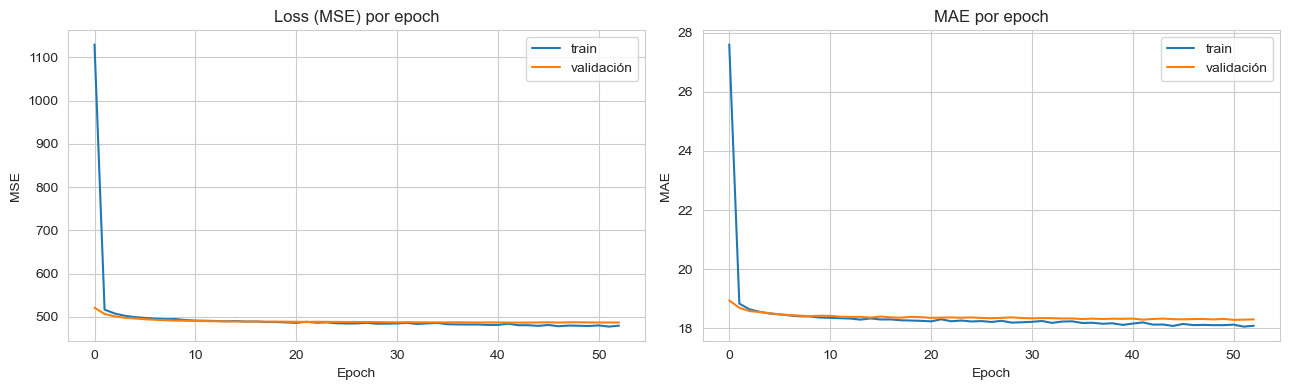

Métricas finales tras el entrenamiento:
  Train      - loss (MSE): 479.647  MAE: 18.083
  Validación - loss (MSE): 486.906  MAE: 18.300


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Curva de pérdida (MSE)
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='validación')
axes[0].set_title('Loss (MSE) por epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE'); axes[0].legend()

# Curva de MAE
axes[1].plot(history.history['mae'], label='train')
axes[1].plot(history.history['val_mae'], label='validación')
axes[1].set_title('MAE por epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE'); axes[1].legend()

plt.tight_layout()
plt.savefig('curvas_entrenamiento_nn.png', dpi=120, bbox_inches='tight')
plt.show()

# Métricas finales en el conjunto de validación (último valor de cada lista)

print(f'Métricas finales tras el entrenamiento:')
print(f'  Train      - loss (MSE): {history.history["loss"][-1]:.3f}  MAE: {history.history["mae"][-1]:.3f}')
print(f'  Validación - loss (MSE): {history.history["val_loss"][-1]:.3f}  MAE: {history.history["val_mae"][-1]:.3f}')

### Evalúe los resultados  para el conjunto de test.

In [22]:
# .ravel() comprime el array a 1D para que tenga la misma forma que y_test

y_pred_nn = model_nn.predict(X_test_scaled, verbose=0).ravel()

# Calculamos las tres métricas. np.sqrt(MSE) = RMSE

mae_nn  = mean_absolute_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
r2_nn   = r2_score(y_test, y_pred_nn)

print(f'Red neuronal — MAE:  {mae_nn:.3f}')
print(f'Red neuronal — RMSE: {rmse_nn:.3f}')
print(f'Red neuronal — R²:   {r2_nn:.3f}')

Red neuronal — MAE:  17.886
Red neuronal — RMSE: 21.751
Red neuronal — R²:   0.111


## Ajuste de modelos de Regresión alternativos

Elegimos como modelo alternativo no basado en redes neuronales un **Random Forest Regressor** ya que:

1. **Capta relaciones no lineales sin esfuerzo.** Como ya vimos, las correlaciones lineales con la popularidad son bajas, por lo que una regresión lineal sería un mal modelo de referencia.
2. **No necesita datos escalados:** a los árboles no tienen en cuenta la magnitud de las variables.
3. **Devuelve la importancia de cada variable:** información útil para discutir los resultados.

**Parámetros relevantes:**

- `n_estimators=200`: número de árboles. Más árboles = predicción más estable, a coste de tiempo.
- `max_depth=None`: dejamos crecer los árboles libremente (sin limitar profundidad).
- `min_samples_leaf=2`: cada hoja debe tener al menos 2 muestras, para evitar hojas con un único caso que sobreajustarían.
- `random_state=SEED`: reproducibilidad.
- `n_jobs=-1`: usa todos los núcleos de CPU disponibles (más rápido).

In [23]:
# Entrenamiento del Random Forest. 

model_rf = RandomForestRegressor( # Le pasamos los datos SIN escalar porque los árboles no lo necesitan
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1
)
model_rf.fit(X_train, y_train)

# Predicciones y métricas en test, para comparar después con la red neuronal

y_pred_rf = model_rf.predict(X_test)
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print(f'Random Forest — MAE:  {mae_rf:.3f}')
print(f'Random Forest — RMSE: {rmse_rf:.3f}')
print(f'Random Forest — R²:   {r2_rf:.3f}')

Random Forest — MAE:  17.810
Random Forest — RMSE: 21.718
Random Forest — R²:   0.113


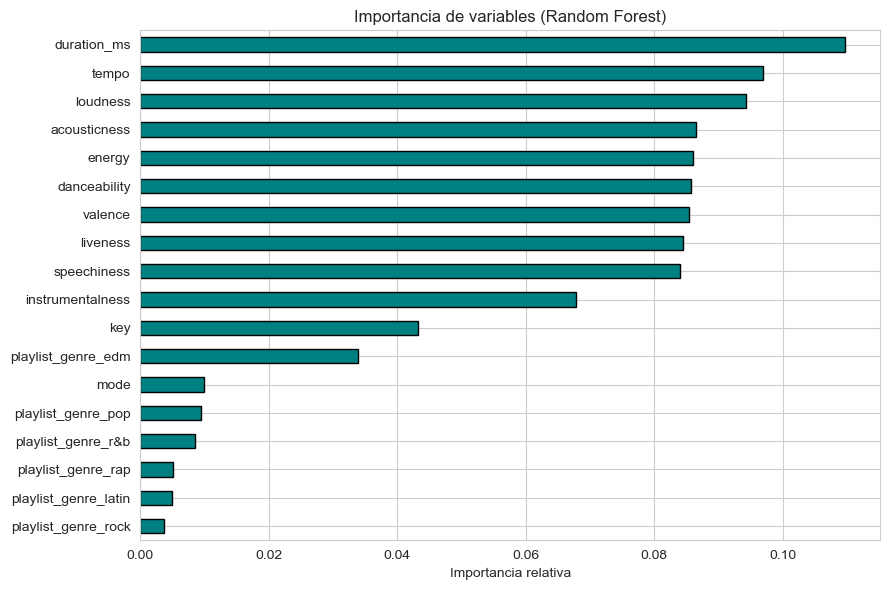

In [24]:
# Importancias de variables según el RF: cuánto contribuye cada feature a reducir el error en los árboles

importancias = pd.Series(model_rf.feature_importances_, index=feature_names)
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(9, 6))
importancias.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Importancia de variables (Random Forest)')
plt.xlabel('Importancia relativa')
plt.tight_layout()
plt.savefig('importancia_variables_rf.png', dpi=120, bbox_inches='tight')
plt.show()

**Principales hallazgos del Random Forest.** Las tres métricas de este modelo son ligeramente mejores que los de la red neuronal (aunque obviamente, estos valores exactos dependen de la ejecución o más bien de la semilla utilizada). Las variables a las que el bosque da más peso son `duration_ms`, `loudness`, `tempo` e `instrumentalness`. Como ya esperábamos, este resultado es coherente: lo que más diferencia a una canción popular de una que no lo es, no es una variable individual sino las combinaciones de varias.

## Comparación del desempeño de modelos

Mostramos los resultados obtenidos por los diferentes algoritmos escogidos de forma gráfica y comparada/superpuesta.

In [25]:
# Tabla resumen con las tres métricas para cada modelo.
resultados = pd.DataFrame({
    'Modelo': ['Red neuronal (Keras)', 'Random Forest'],
    'MAE':  [mae_nn,  mae_rf],
    'RMSE': [rmse_nn, rmse_rf],
    'R²':   [r2_nn,   r2_rf]
})
resultados

,Modelo,MAE,RMSE,R²
0,Red neuronal (Keras),17.885996,21.751096,0.110546
1,Random Forest,17.809917,21.718077,0.113245


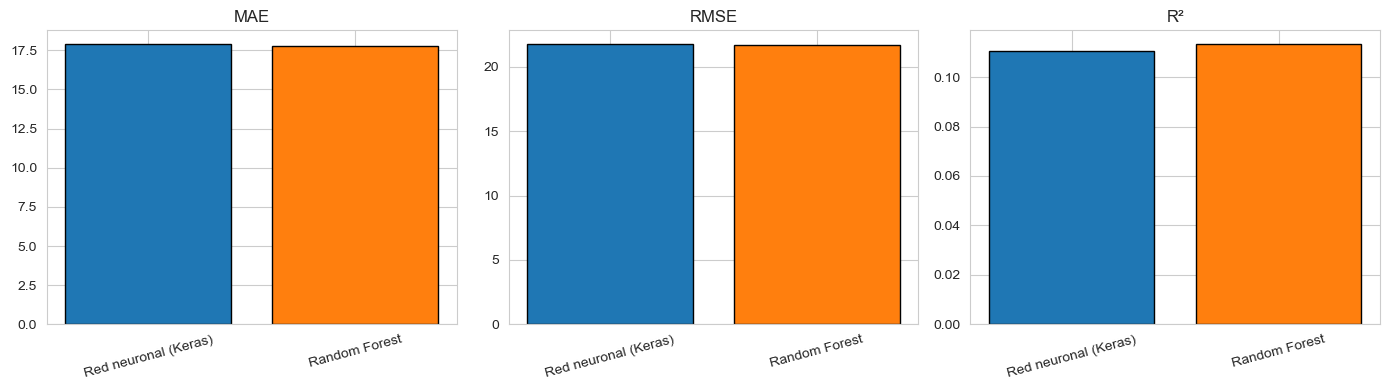

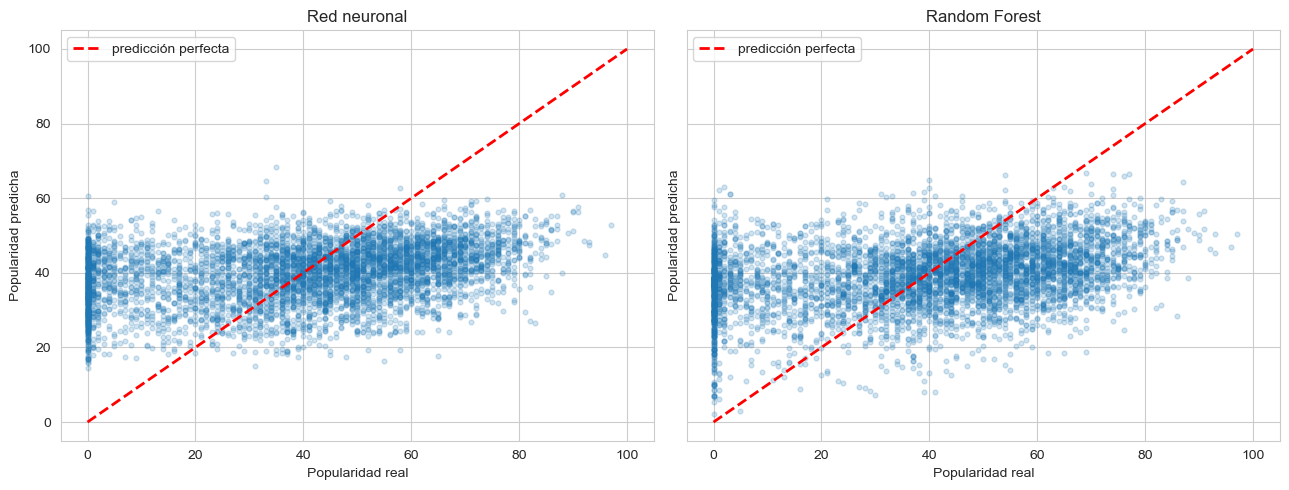

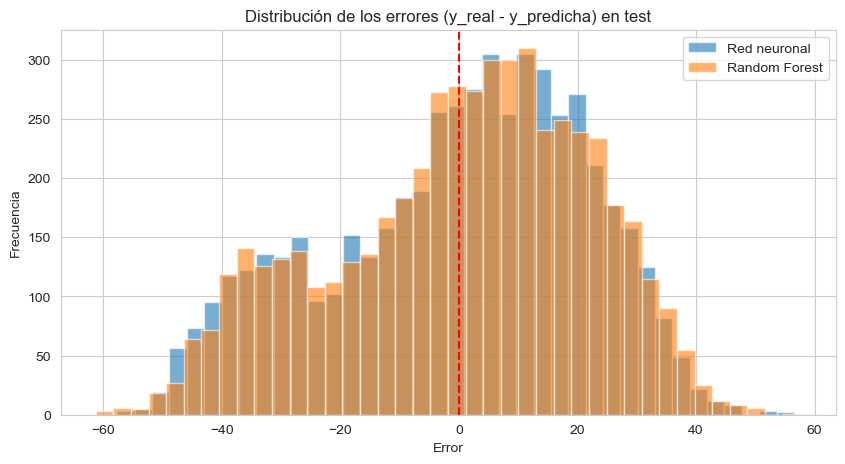

In [26]:
# Tres gráficas de barras (una por cada métrica) + dos scatter plots de real vs predicho + histograma de errores.

# Lo agrupamos todo en una sola celda para que la comparación quede visualmente unificada.

# (a) Barras: comparación de cada métrica
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, met in zip(axes, ['MAE', 'RMSE', 'R²']):
    ax.bar(resultados['Modelo'], resultados[met], color=['#1f77b4', '#ff7f0e'], edgecolor='black')
    ax.set_title(met)
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('comparacion_metricas.png', dpi=120, bbox_inches='tight')
plt.show()

# (b) Scatter real vs predicho: si los puntos cayeran sobre la diagonal roja, el modelo sería perfecto.
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, y_pred, titulo in zip(axes, [y_pred_nn, y_pred_rf], ['Red neuronal', 'Random Forest']):
    ax.scatter(y_test, y_pred, alpha=0.2, s=12)
    ax.plot([0, 100], [0, 100], 'r--', linewidth=2, label='predicción perfecta')
    ax.set_xlabel('Popularidad real')
    ax.set_ylabel('Popularidad predicha')
    ax.set_title(titulo)
    ax.legend()
plt.tight_layout()
plt.savefig('real_vs_predicho.png', dpi=120, bbox_inches='tight')
plt.show()

# (c) Histogramas de errores superpuestos. Un buen modelo tiene errores centrados en 0 y estrechos.
errores_nn = y_test - y_pred_nn
errores_rf = y_test - y_pred_rf
plt.figure(figsize=(10, 5))
plt.hist(errores_nn, bins=40, alpha=0.6, label='Red neuronal', color='#1f77b4')
plt.hist(errores_rf, bins=40, alpha=0.6, label='Random Forest', color='#ff7f0e')
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribución de los errores (y_real - y_predicha) en test')
plt.xlabel('Error'); plt.ylabel('Frecuencia')
plt.legend()
plt.savefig('distribucion_errores.png', dpi=120, bbox_inches='tight')
plt.show()

**Principales hallazgos.** Las tres métricas señalan al Random Forest como el modelo con mejor desempeño en este problema: MAE y RMSE algo menores y R² algo mayor. Las gráficas de real vs. predicho muestran un patrón muy parecido en los dos modelos: ambos aprenden la tendencia central de la popularidad pero les cuesta acertar en los extremos (canciones con popularidad cercana a 0 o muy cercana a 100). Los histogramas de errores están centrados en 0 en los dos casos, pero la dispersión es grande, lo cual tiene sentido dado el R².

## Discusión de los resultados obtenidos y argumentos sobre cómo se podrían mejorar de dichos resultados

**Resultados comparados.** El Random Forest se ha comportado algo mejor que la red neuronal, lo cual no me sorprende ya que en problemas tabulares de tamaño medio, los modelos basados en ensamble de árboles suelen ganar a las redes densas porque captan interacciones muy bien y son menos sensibles a los hiperparámetros. Las redes neuronales empiezan a brillar cuando hay muchos más datos (cientos de miles o millones de muestras) o cuando la entrada tiene estructura (imágenes, audio, texto).

**Conclusión objetiva.** Ningún modelo alcanza un R² alto, lo cual confirma nuestra intuición de partida, y es que, predecir la popularidad solo a partir de características de audio no es muy acertado. Esto nos lleva a que la popularidad real depende de factores externos al audio (artista, marketing, momento del lanzamiento, viralidad en redes…), muchos factores que el dataset no incluye. Los gráficos de real vs. predicho lo dejan ver: los modelos predicen bien la zona central, pero fallan en los extremos.

**Cómo se podrían mejorar los resultados:**

+ **Búsqueda de hiperparámetros**: probar arquitecturas distintas (más capas, distintos números de neuronas), otros learning rates, otros tamaños de batch, otros optimizadores. Una búsqueda con `KerasTuner` o un `GridSearchCV` sobre el Random Forest podrían sacar bastante margen.
+ **Regularización adicional en la red**: ya hemos usado Dropout, pero se podría añadir regularización L2 (`kernel_regularizer`) o BatchNormalization para estabilizar el entrenamiento.
+ **Función de pérdida más robusta**: dado el pico de canciones con popularidad 0, una loss tipo Huber sería menos sensible a esos outliers y podría dar mejores resultados.
+ **Más features**: incorporar información del artista (popularidad histórica, número de seguidores...), del momento de publicación (año, mes), o variables externas como tirón en redes sociales.
+ **Más datos**: la API de Spotify permite obtener millones de canciones. Con más volumen, la red neuronal ganaría ventaja sobre el Random Forest.
+ **Validación cruzada**: he usado un único split train/test, hacer k-fold daría una estimación más fiable de las métricas.